<a href="https://colab.research.google.com/github/Muhammad-Huzzaifa/urdu-question-generation/blob/main/notebooks/urdu_question_generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install datasets sentencepiece sacrebleu rouge-score torch

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 6.6 MB/s eta 0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24986 sha256=afabd7b1821e7818ee48db740e7f4fad7f4b897e4680a6a1274db6dc3e16b22e
  Stored in directory: /root/.cache/pip/wheels/44/af/da/5ffc433e2786f0b1a9c6f458d5fb8f611d8eb332387f18698f
Successfully built rouge-score


In [21]:
from datasets import load_dataset
import csv
import matplotlib.pyplot as plt

In [3]:
ds = load_dataset("uqa/UQA")
print(ds)

README.md:   0%|          | 0.00/898 [00:00<?, ?B/s]

data/train-00000-of-00001-bac007e8ca7192(…): reconstructing file:   0%|          |  0.00B / 30.2MB            

data/train-00000-of-00001-bac007e8ca7192(…): downloading bytes:           |  0.00B            

data/validation-00000-of-00001-cf8a6960d(…): reconstructing file:   0%|          |  0.00B / 2.92MB            

data/validation-00000-of-00001-cf8a6960d(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/124745 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/16824 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start'],
        num_rows: 124745
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start'],
        num_rows: 16824
    })
})


In [4]:
ex = ds["train"][0]
print(ex.keys)

<built-in method keys of dict object at 0x7d75ad6a1b80>


In [5]:
print(ex["question"])
print(ex["answer"])

بیونس نے کب مقبولیت حاصل کرنا شروع کی؟
1990 کی دہائی کے آخر میں


In [6]:
n_total = len(ds["train"])
n_ans = n_total - sum(ds["train"]["is_impossible"])
print (f"train rows: {n_total}, answerable: {n_ans}")

train rows: 124745, answerable: 83018


In [22]:
ANS_OPEN, ANS_CLOSE = "<ans>", "</ans>"
SENT_DELIMS = "\u06D4\u061F!"

In [8]:
def split_sentences(text):
    start = 0
    for i, ch in enumerate(text):
        if ch in SENT_DELIMS:
            yield start, i + 1, text[start : i + 1]
            start = i + 1
    if start < len(text):
        yield start, len(text), text[start:]

In [9]:
def make_pair(example, max_src=60, max_tgt=25):
    if example["is_impossible"]:
        return None
    a_start = example["answer_start"]
    a_text = example["answer"]
    a_end = a_start + len(a_text)
    context = example["context"]
    for s, e, sent in split_sentences(context):
        if s <= a_start < e:
            rel = a_start - s
            if sent[rel : rel + len(a_text)] != a_text:
                return None
            src = sent[:rel] + " " + ANS_OPEN + " " + a_text + " " + ANS_CLOSE + " " + sent[rel + len(a_text) :]
            src = " ".join(src.split())
            tgt = " ".join(example["question"].split())
            if len(src.split()) > max_src or len(tgt.split()) > max_tgt:
                return None
            return src, tgt
    return None

In [10]:
def build_split(split, out_path):
    pairs = [p for p in map(make_pair, split) if p is not None]
    with open(out_path, "w", encoding="utf-8", newline="") as f:
        w = csv.writer(f, delimiter="\t", quoting=csv.QUOTE_NONE, escapechar="\\")
        w.writerows(pairs)
    print(f"{out_path}: {len(pairs)} pairs")
    return pairs

In [11]:
train_pairs = build_split(ds["train"], "train.tsv")
valid_pairs = build_split(ds["validation"], "valid.tsv")

train.tsv: 75067 pairs
valid.tsv: 10018 pairs


In [12]:
print(f"train: \n\ttotal: {len(ds['train'])} \n\tanswerable: {len(ds['train']) - sum(ds['train']['is_impossible'])} \n\tselected: {len(train_pairs)}\n")
print(f"validation: \n\ttotal: {len(ds['validation'])} \n\tanswerable: {len(ds['validation']) - sum(ds['validation']['is_impossible'])} \n\tselected: {len(valid_pairs)}\n")

train: 
	total: 124745 
	answerable: 83018 
	selected: 75067

validation: 
	total: 16824 
	answerable: 11169 
	selected: 10018



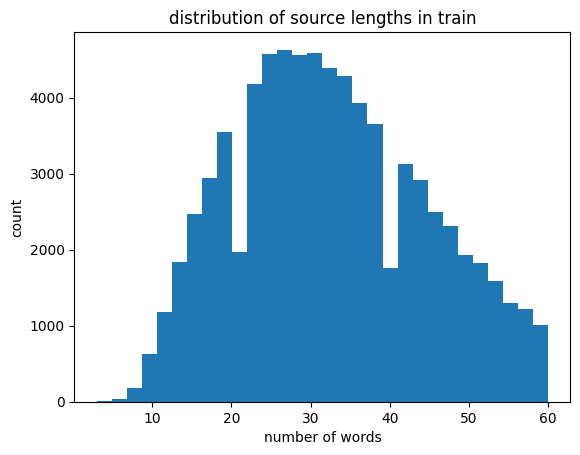

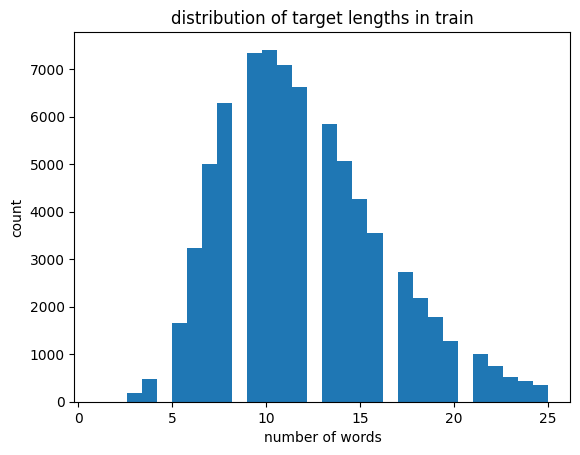

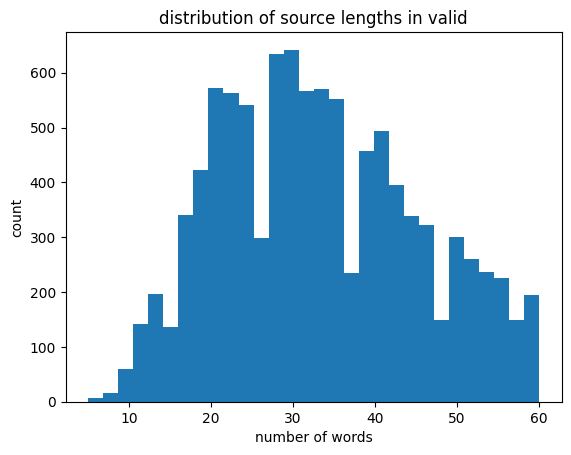

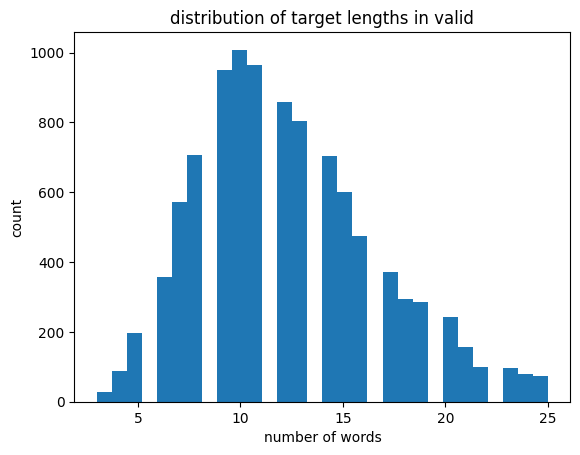

In [19]:
plt.figure()
plt.hist([len(src.split()) for src, _ in train_pairs], bins=30, label="train source")
plt.title("distribution of source lengths in train")
plt.xlabel("number of words")
plt.ylabel("count")
plt.show()

plt.figure()
plt.hist([len(tgt.split()) for _, tgt in train_pairs], bins=30, label="train target")
plt.title("distribution of target lengths in train")
plt.xlabel("number of words")
plt.ylabel("count")
plt.show()

plt.figure()
plt.hist([len(src.split()) for src, _ in valid_pairs], bins=30, label="valid source")
plt.title("distribution of source lengths in valid")
plt.xlabel("number of words")
plt.ylabel("count")
plt.show()

plt.figure()
plt.hist([len(tgt.split()) for _, tgt in valid_pairs], bins=30, label="valid target")
plt.title("distribution of target lengths in valid")
plt.xlabel("number of words")
plt.ylabel("count")
plt.show()

In [14]:
import sentencepiece as spm

In [15]:
with open("sp_corpus.txt", "w", encoding="utf-8") as f:
    for src, tgt in train_pairs:
        f.write(src + "\n" + tgt + "\n")

In [16]:
spm.SentencePieceTrainer.train(
    input="sp_corpus.txt",
    model_prefix="ur_sp",
    vocab_size=8000,
    model_type="unigram",
    character_coverage=1.0,
    user_defined_symbols=[ANS_OPEN, ANS_CLOSE],
    pad_id=0, unk_id=1, bos_id=2, eos_id=3,
)

True

In [17]:
sp = spm.SentencePieceProcessor(model_file="ur_sp.model")
PAD, UNK, BOS, EOS = 0, 1, 2, 3
src, tgt = train_pairs[0]
print(sp.encode(src, out_type=str))
print(sp.encode(tgt))
print(sp.decode(sp.encode(tgt)) == tgt)

['▁ہیوسٹن', '▁،', '▁ٹیکساس', '▁میں', '▁پیدا', '▁ہوئی', '▁اور', '▁اس', '▁کی', '▁پرورش', '▁ہوئی', '▁،', '▁اس', '▁نے', '▁بچپن', '▁میں', '▁مختلف', '▁گانے', '▁اور', '▁رقص', '▁کے', '▁مقابلوں', '▁میں', '▁پرفارم', '▁کیا', '▁،', '▁اور', '▁', '<ans>', '▁1990', '▁کی', '▁دہائی', '▁کے', '▁آخر', '▁میں', '▁', '</ans>', '▁R', '&', 'B', '▁گر', 'ل', '▁گروپ', '▁ڈسٹنی', '▁چائلڈ', '▁کے', '▁لیڈ', '▁گلوکار', '▁کی', '▁حیثیت', '▁سے', '▁شہرت', '▁حاصل', '▁کی۔']
[2757, 18, 83, 2810, 100, 151, 99, 9, 11]
True


In [18]:
for src, _ in train_pairs[:5]:
    print(f"original: {src}\ntokenized: {sp.encode(src, out_type=str)}\n\n")

original: ہیوسٹن ، ٹیکساس میں پیدا ہوئی اور اس کی پرورش ہوئی ، اس نے بچپن میں مختلف گانے اور رقص کے مقابلوں میں پرفارم کیا ، اور <ans> 1990 کی دہائی کے آخر میں </ans> R&B گرل گروپ ڈسٹنی چائلڈ کے لیڈ گلوکار کی حیثیت سے شہرت حاصل کی۔
tokenized: ['▁ہیوسٹن', '▁،', '▁ٹیکساس', '▁میں', '▁پیدا', '▁ہوئی', '▁اور', '▁اس', '▁کی', '▁پرورش', '▁ہوئی', '▁،', '▁اس', '▁نے', '▁بچپن', '▁میں', '▁مختلف', '▁گانے', '▁اور', '▁رقص', '▁کے', '▁مقابلوں', '▁میں', '▁پرفارم', '▁کیا', '▁،', '▁اور', '▁', '<ans>', '▁1990', '▁کی', '▁دہائی', '▁کے', '▁آخر', '▁میں', '▁', '</ans>', '▁R', '&', 'B', '▁گر', 'ل', '▁گروپ', '▁ڈسٹنی', '▁چائلڈ', '▁کے', '▁لیڈ', '▁گلوکار', '▁کی', '▁حیثیت', '▁سے', '▁شہرت', '▁حاصل', '▁کی۔']


original: ہیوسٹن ، ٹیکساس میں پیدا اور پرورش پائی ، اس نے بچپن میں مختلف <ans> گانے اور رقص </ans> کے مقابلوں میں پرفارم کیا ، اور 1990 کی دہائی کے آخر میں آر اینڈ بی گرل گروپ ڈسٹنی چائلڈ کی لیڈ گلوکارہ کی حیثیت سے شہرت حاصل کی۔
tokenized: ['▁ہیوسٹن', '▁،', '▁ٹیکساس', '▁میں', '▁پیدا', '▁اور', '▁پرورش', '▁پائی', '▁،

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

In [24]:
class Encoder(nn.Module):

    def __init__(self, input_size, hidden_size, num_layers, dropout):
        """encoder initializer

        Args:
            input_size (int): size of the input
            hidden_size (int): size of the hidden state
            num_layers (int): number of layers in the lstm
            dropout (float): dropout rate
        """
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            bidirectional=True,
        )
        self.hidden = nn.Linear(hidden_size * 2, hidden_size)
        self.cell = nn.Linear(hidden_size * 2, hidden_size)

    def forward(self, x, lengths):
        """forward pass of the encoder

        Args:
            x (tensor): input tensor of shape (s_seq_len, batch_size, embedding_dim)
            lengths (tensor): a tensor of shape (batch_size,) containing the actual lengths of the sequences in the batch

        Returns:
            tuple: a tuple containing the projected sequence hidden states of shape (s_seq_len, batch_size, hidden_size), final projected hidden and cell states of shape (num_layers, batch, hidden_size)
        """
        x = pack_padded_sequence(x, lengths.cpu(), enforce_sorted=False)
        packed_outputs, (hidden, cell) = self.lstm(x)
        outputs, _ = pad_packed_sequence(packed_outputs)

        return self.hidden(outputs), self.hidden(torch.cat((hidden[::2], hidden[1::2]), dim=2)), self.cell(torch.cat((cell[::2], cell[1::2]), dim=2))

In [25]:
class LuongAttention(nn.Module):

    def __init__(self):
        """initializer of luong's global attention with dot score
        """
        super().__init__()

    def forward(self, enc_hiddens, dec_hidden, mask):
        """computing the context vector according to luong's global attention with dot score

        Args:
            enc_hiddens (tensor): encoder hidden states of shape (s_seq_len, batch_size, hidden_size)
            dec_hidden (tensor): decoder hidden state of shape (batch_size, hidden_size)
            mask (tensor): a tensor of shape (batch_size, s_seq_len) containing 1s for valid positions and 0s for padded positions

        Returns:
            tensor: context vector of shape (batch_size, hidden_size)
        """
        scores = enc_hiddens.transpose(0, 1) @ dec_hidden.unsqueeze(2)
        scores = scores.masked_fill(mask.unsqueeze(2) == 0, float("-inf"))
        attn_weights = F.softmax(scores, dim=1)
        context = attn_weights.transpose(1, 2) @ enc_hiddens.transpose(0, 1)

        return context.squeeze(1)

In [26]:
class Decoder(nn.Module):

    def __init__(self, attention, vocab_size, input_size, hidden_size, num_layers, dropout):
        """initializer of the decoder with attention

        Args:
            attention (LuongAttention): an instance of the LuongAttention class
            vocab_size (int): size of the vocabulary
            input_size (int): size of the input embeddings
            hidden_size (int): size of the hidden states
            num_layers (int): number of layers in the lstm
            dropout (float): dropout rate
        """
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size + hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
        )
        self.attention = attention
        self.h_att_layer = nn.Linear(2 * hidden_size, hidden_size)
        self.out_layer = nn.Linear(hidden_size, vocab_size)

    def forward(self, y_prev, h_att_prev, h_prev, c_prev, encoder_hiddens, mask):
        """forward pass of the decoder with attention

        Args:
            y_prev (tensor): previous embedded output of the decoder of shape (batch_size, embedding_dim)
            h_att_prev (tensor): previous attention-hidden state of shape (batch_size, hidden_size)
            h_prev (tensor): previous hidden state of the lstm of shape (num_layers, batch_size, hidden_size)
            c_prev (tensor): previous cell state of the lstm of shape (num_layers, batch_size, hidden_size)
            encoder_hiddens (tensor): encoder hidden states of shape (s_seq_len, batch_size, hidden_size)
            mask (tensor): a tensor of shape (batch_size, s_seq_len) containing 1s for valid positions and 0s for padded positions

        Returns:
            tuple: a tuple containing the logit output of shape (batch_size, vocab_size), attention-hidden state of shape (batch_size, hidden_size), hidden state of shape (num_layers, batch_size, hidden_size), and cell state of shape (num_layers, batch_size, hidden_size)
        """
        x = torch.cat((y_prev, h_att_prev), dim=1).unsqueeze(0)
        output, (hidden, cell) = self.lstm(x, (h_prev, c_prev))

        context = self.attention(encoder_hiddens, output.squeeze(0), mask)
        h_att = F.tanh(self.h_att_layer(torch.cat((context, output.squeeze(0)), dim=1)))
        logits = self.out_layer(h_att)

        return logits, h_att, hidden, cell

In [27]:
class Seq2Seq(nn.Module):

    def __init__(self, device, pad_idx, sos_idx, eos_idx, vocab_size, embedding_dim, hidden_dim, num_layers, dropout):
        """initializer of the seq2seq model with attention

        Args:
            device (torch.device): device to run the model on
            pad_idx (int): index of the padding token
            sos_idx (int): index of the start-of-sequence token
            eos_idx (int): index of the end-of-sequence token
            vocab_size (int): size of the vocabulary
            embedding_dim (int): dimension of the embedding layer
            hidden_dim (int): dimension of the hidden layer
            num_layers (int): number of layers in the lstm
            dropout (float): dropout probability
        """
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.attention = LuongAttention()
        self.encoder = Encoder(embedding_dim, hidden_dim, num_layers, dropout)
        self.decoder = Decoder(self.attention, vocab_size, embedding_dim, hidden_dim, num_layers, dropout)
        self.dropout = nn.Dropout(dropout)
        self.device = device
        self.pad_idx = pad_idx
        self.sos_idx = sos_idx
        self.eos_idx = eos_idx

    def forward(self, x, lengths, y, teacher_forcing_ratio=0.5):
        """complete end to end forward pass of seq2seq model

        Args:
            x (tensor): input sequence of shape (s_seq_len, batch_size)
            lengths (tensor): lengths of the input sequences
            y (tensor): target sequence of shape (t_seq_len, batch_size)
            teacher_forcing_ratio (float, optional): probability of using teacher forcing, defaults to 0.5

        Returns:
            tuple: a tuple containing the output logits of shape (t_seq_len - 1, batch_size, vocab_size)
        """
        embedded_x = self.dropout(self.embedding(x))
        encoder_hiddens, hidden, cell = self.encoder(embedded_x, lengths)

        outputs = torch.zeros((y.size(0) - 1, y.size(1), self.decoder.out_layer.out_features), device=self.device)

        mask = (x != self.pad_idx).transpose(0, 1)
        y_prev_token = y[0]
        h_att = torch.zeros((x.size(1), hidden.size(2)), device=self.device)

        for t in range(1, y.size(0)):
            embedded_y_prev = self.dropout(self.embedding(y_prev_token))
            logits, h_att, hidden, cell = self.decoder(embedded_y_prev, h_att, hidden, cell, encoder_hiddens, mask)
            outputs[t - 1] = logits
            y_prev_token = y[t] if torch.rand(1) < teacher_forcing_ratio else logits.argmax(1)

        return outputs

    @torch.no_grad()
    def decode(self, x, lengths, max_len, beam_size=1):
        """decodes the input sequence into a list of predicted sequences

        Args:
            x (tensor): input sequence of shape (s_seq_len, batch_size)
            lengths (tensor): lengths of the input sequences shape is (batch_size,)
            max_len (int): maximum length of the output sequences
            beam_size (int, optional): number of beams to use for decoding defaults is 1 (greedy)

        Returns:
            list: a list of predicted sequences, each sequence is a list of token indices of shape (batch_size, max_len)
        """
        self.eval()

        embedded_x = self.embedding(x)
        enc_hiddens, enc_hidden, enc_cell = self.encoder(embedded_x, lengths)

        mask = (x != self.pad_idx).transpose(0, 1)

        results = []

        for b in range(x.size(1)):
            enc_hiddens_b = enc_hiddens[:, b : b + 1, :]
            enc_hidden_b = enc_hidden[:, b : b + 1, :]
            enc_cell_b = enc_cell[:, b : b + 1, :]
            mask_b = mask[b : b + 1, :]
            h_att_b = torch.zeros((1, enc_hidden.size(2)), device=self.device)

            beams = [(
                0.0,
                [self.sos_idx],
                h_att_b,
                enc_hidden_b,
                enc_cell_b,
                False
            )]

            for _ in range(max_len):
                if all(beam[-1] for beam in beams):
                    break

                new_beams = []
                for score, tokens, h_att_prev, h_prev, c_prev, finished in beams:
                    if finished:
                        new_beams.append((score, tokens, h_att_prev, h_prev, c_prev, finished))
                        continue


                    y_prev_token = torch.tensor([tokens[-1]], device=self.device)
                    embedded_y_prev = self.embedding(y_prev_token)
                    logits, h_att, h, c = self.decoder(embedded_y_prev, h_att_prev, h_prev, c_prev, enc_hiddens_b, mask_b)
                    logp = F.log_softmax(logits, dim=1).squeeze(0)
                    topk_logp, topk_idxs = logp.topk(beam_size)

                    for logp, idx in zip(topk_logp.tolist(), topk_idxs.tolist()):
                        new_token = tokens + [idx]
                        new_score = score + logp
                        new_finished = finished or (idx == self.eos_idx)
                        new_beams.append((new_score, new_token, h_att, h, c, new_finished))

                beams = sorted(new_beams, key=lambda x: x[0], reverse=True)[:beam_size]

            best_beam = max(beams, key=lambda x: x[0])
            results.append(best_beam[1][1:-1] if best_beam[-1] else best_beam[1][1:])

        return results